<a href="https://colab.research.google.com/github/Adi13102005/Simple_Python_Program/blob/main/Prac6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
dataset=files.upload()

Saving titanic.csv to titanic.csv


In [4]:
import pandas as pd
import numpy as np


In [5]:
df = pd.read_csv('titanic.csv')

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [19]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDataFrame Info:\n")
df.info()
print("\nDescriptive Statistics:\n", df.describe())

Missing values per column:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
AgeGroup       0
dtype: int64

DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    object  
 11  AgeGroup     891 non-null    category
dtypes: category(1), float64(2

## Handle Missing Values




In [21]:
df['Age'] = df['Age'].fillna(df['Age'].median())
if 'Cabin' in df.columns:
    df = df.drop('Cabin', axis=1)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Missing values after handling:\n", df.isnull().sum())

Missing values after handling:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
AgeGroup       0
dtype: int64


## Preprocess Data




In [11]:
bins = [0, 12, 19, 30, 50, 80]
labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
print("Value counts for AgeGroup:\n", df['AgeGroup'].value_counts())

Value counts for AgeGroup:
 AgeGroup
Young Adult    422
Adult          241
Teenager        95
Child           69
Senior          64
Name: count, dtype: int64


## Visualize Survival Rates




/tmp/ipykernel_803/3517562971.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_agegroup = df.groupby('AgeGroup')['Survived'].mean().reset_index()


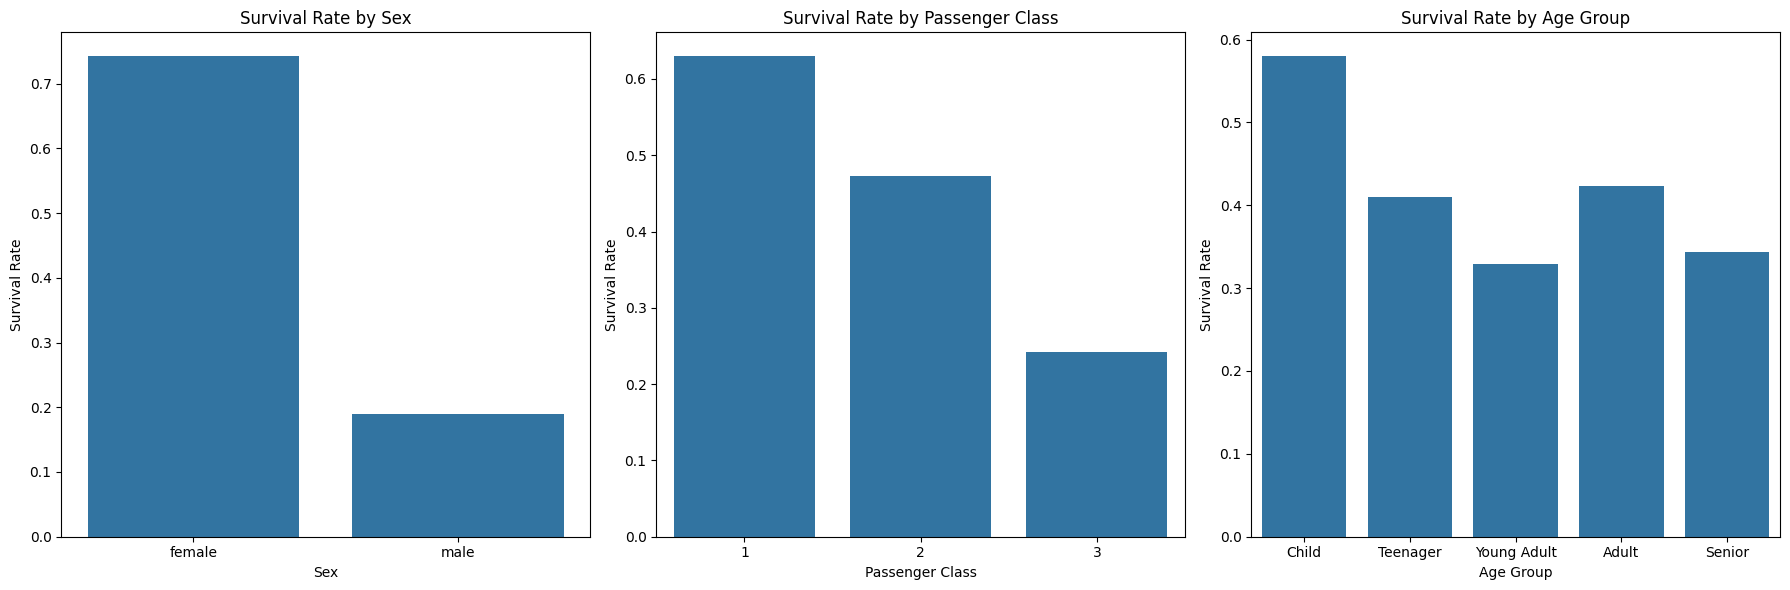

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for the plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Survival rate by Sex
survival_by_sex = df.groupby('Sex')['Survived'].mean().reset_index()
sns.barplot(x='Sex', y='Survived', data=survival_by_sex, ax=axes[0])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Survival Rate')

# Survival rate by Pclass
survival_by_pclass = df.groupby('Pclass')['Survived'].mean().reset_index()
sns.barplot(x='Pclass', y='Survived', data=survival_by_pclass, ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')

# Survival rate by AgeGroup
survival_by_agegroup = df.groupby('AgeGroup')['Survived'].mean().reset_index()
sns.barplot(x='AgeGroup', y='Survived', data=survival_by_agegroup, ax=axes[2])
axes[2].set_title('Survival Rate by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

## Define Conditional Cases and Operations

### Subtask:
Define how 'FamilySize' will be calculated from 'SibSp' and 'Parch', and how 'IsAlone' will be derived from 'FamilySize'.


In [24]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

print("DataFrame with new 'FamilySize' and 'IsAlone' columns (first 5 rows):\n", df.head())
print("\nValue counts for 'IsAlone':\n", df['IsAlone'].value_counts())

DataFrame with new 'FamilySize' and 'IsAlone' columns (first 5 rows):
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked     AgeGroup  FamilySize  IsAlone  
0      0         A/5 21171   7.2500        S  Young Adult           2        0  
1      0          PC 17599  71.2833        C        Adult           2        0  
2     

In [25]:
print("Descriptive statistics for 'FamilySize':\n", df['FamilySize'].describe())
print("\nValue counts for 'FamilySize':\n", df['FamilySize'].value_counts())
print("\nDescriptive statistics for 'IsAlone':\n", df['IsAlone'].describe())
print("\nValue counts for 'IsAlone':\n", df['IsAlone'].value_counts())

Descriptive statistics for 'FamilySize':
 count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64

Value counts for 'FamilySize':
 FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

Descriptive statistics for 'IsAlone':
 count    891.000000
mean       0.602694
std        0.489615
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: IsAlone, dtype: float64

Value counts for 'IsAlone':
 IsAlone
1    537
0    354
Name: count, dtype: int64
